# NFL Player Performance — Eksplorativna Analiza Podataka

Ovaj notebook predstavlja strukturiranu, kompletnu eksplorativnu analizu podataka za NFL igrače po pozicijama:

QB (quarterback), RB (running back), TE (tight end) i WR (wide receiver).

| Position | Data Source | Method |
|----------|-------------|--------|
| Quarterback | [Pro Football Reference](https://www.pro-football-reference.com) and [NFL Elo](https://www.nfeloapp.com/qb-rankings/) | Selenium web scraper and pre-built dataset |
| Running Back | [Pro Football Reference](https://www.pro-football-reference.com) | Selenium web scraper |
| Tight End | [Pro Football Reference](https://www.pro-football-reference.com) | Selenium web scraper |
| Wide Receiver | [HuggingFace / nflverse](https://huggingface.co/datasets/SebastianAndreu/24679_NFL_WR_Dataset_2025) | Pre-built dataset |

In [127]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from notebook_setup import *
from notebook_setup import setup
setup()

In [128]:
DATA_DIR = os.path.join("..", "data", "fully combined")

qb = pd.read_csv(os.path.join(DATA_DIR, "qb_master.csv"))
rb = pd.read_csv(os.path.join(DATA_DIR, "rb_master.csv"))
te = pd.read_csv(os.path.join(DATA_DIR, "te_master.csv"))
wr_seasons = pd.read_csv(os.path.join(DATA_DIR, "wr_all_seasons.csv"))

datasets = {
    "QB (qb_master)":          qb,
    "RB (rb_master)":          rb,
    "TE (te_master)":          te,
    "WR (wr_all_seasons)": wr_seasons,
}

print("Skupovi podataka uspješno učitani:\n")
for name, df in datasets.items():
    print(f"  {name:40s}    {df.shape[0]:>6} redova  ×  {df.shape[1]:>3} kolona")

Skupovi podataka uspješno učitani:

  QB (qb_master)                                 845 redova  ×  186 kolona
  RB (rb_master)                                 622 redova  ×  113 kolona
  TE (te_master)                                 194 redova  ×   60 kolona
  WR (wr_all_seasons)                           5529 redova  ×   99 kolona


- QB skup ima 845 redova i 186 kolona - najveći broj feature-a zbog kombinacije standardnih sezonskih statistika, naprednih passing metrika, ELO rejting komponenti i snap count podataka. Svaki red = jedna sezona jednog QB-a.
- RB skup ima 622 redova i 113 kolona - uključuje rushing i receiving statistike, napredne metrike poput broken tackles i YBC/YAC, te defensive i snap count kolone.
- TE skup je najmanji sa 194 reda i 60 kolona - fokusiran na receiving i rush statistike tight end-ova.
- WR Seasons je najobimniji skup sa 5.529 redova i 99 kolona - prikupljen iz nflverse/nflfastR izvora i sadrži kontekstualne varijable (situacione metrike, VP sekcije, vremenske uslove).

In [129]:
for name, df in datasets.items():
    print(f"{'_'*70}")
    print(f"  {name}")
    display(df.head(3))

______________________________________________________________________
  QB (qb_master)


,Player,PlayerID,Season,Age,Team,Pos,G,GS,QBrec,Cmp,Att,Cmp%,Yds,TD,TD%,Int,Int%,1D,Succ%,Lng,Y/A,AY/A,Y/C,Y/G,Rate,...,elo_Penalties,elo_Points,elo_QB Elo,elo_QBR,elo_Rushing,elo_Sacks,elo_Sacks.1,elo_Starts,elo_Success,elo_T,elo_TD%,elo_TD%-INT%,elo_TDs,elo_TDs.1,elo_Total,elo_Total WPA,elo_W,elo_WPA / DB,elo_YAC,elo_YPA,elo_YPC,elo_Yards,elo_Yards.1,elo_aDOT,elo_vs Sticks
0,Josh Allen,AlleJo02,2018,22,BUF,QB,12,11,5-6-0,169,320,52.80,2074,10,3.10,12,3.80,89,37.10,75.00,6.50,5.42,12.30,172.80,67.90,...,-0.01,-0.79,136.35,49.80,0.07,28.00,0.01,11.00,0.43,0.00,0.03,-0.01,10.00,8.00,2.33,-0.18,5.00,-0.00,-0.08,6.41,7.86,2044.00,637.00,11.00,1.37
1,Josh Allen,AlleJo02,2019,23,BUF,QB,16,16,10-6-0,271,461,58.80,3089,20,4.30,9,2.00,146,41.70,53.00,6.70,6.69,11.40,193.10,85.30,...,0.00,-0.13,157.14,49.40,0.03,38.00,0.01,16.00,0.45,0.00,0.04,0.02,20.00,9.00,30.56,1.08,10.00,0.00,-0.07,6.74,5.54,3089.00,521.00,9.31,0.02
2,Josh Allen,AlleJo02,2020,24,BUF,QB,16,16,13-3-0,396,572,69.20,4544,37,6.50,10,1.70,228,56.50,55.00,7.90,8.45,11.50,284.00,107.20,...,-0.00,4.18,294.01,76.60,0.01,26.00,0.04,16.00,0.56,0.00,0.06,0.05,37.00,8.00,207.25,5.30,13.00,0.01,0.01,7.94,5.65,4544.00,441.00,8.49,-0.67


______________________________________________________________________
  RB (rb_master)


,Player,PlayerID,Season,Age,Team,Lg,Pos,G,GS,Rush_Att,Rush_Yds,Rush_TD,Rush_1D,Rush_Succ%,Rush_Lng,Rush_Y/A,Rush_Y/G,Rush_A/G,Tgt,Rec,Rec_Yds,Rec_Y/R,Rec_TD,Rec_1D,Rec_Succ%,...,def_FR,def_FRTD,def_FR_TD,def_FR_Yds,def_Fmb,def_PD,def_QBHits,def_Sfty,def_Sk,def_Solo,def_TFL,def_Tkl_Ast,def_Tkl_Comb,def_Tkl_Solo,def_safety_md,def_tackles_loss,snp_Def%,snp_Def_Snaps,snp_Off%,snp_Off_Snaps,snp_ST%,snp_ST_Snaps,snp_defense,snp_offense,snp_special_teams
0,Saquon Barkley,BarkSa00,2018,21,NYG,NFL,RB,16,16,261,1307,11,50,39.80,78.00,5.00,81.70,16.30,121,91,721,7.90,4,30,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Saquon Barkley,BarkSa00,2019,22,NYG,NFL,RB,13,13,217,1003,6,45,43.30,68.00,4.60,77.20,16.70,73,52,438,8.40,2,14,NaN,...,2.00,0.00,NaN,NaN,1.00,0.00,0.00,NaN,0.00,0.00,NaN,NaN,NaN,NaN,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,0.00,728.00,1.00
2,Saquon Barkley,BarkSa00,2020,23,NYG,NFL,RB,2,2,19,34,0,1,26.30,18.00,1.80,17.00,9.50,9,6,60,10.00,0,3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,67.00,0.00


______________________________________________________________________
  TE (te_master)


,Player,PlayerID,Season,Age,Team,Lg,Pos,G,GS,Tgt,Rec,Rec_Yds,Rec_Y/R,Rec_TD,Rec_1D,rec_success,rec_long,Rec_R/G,Rec_Y/G,catch_pct,Y/Tgt,Rush_Att,Rush_Yds,Rush_TD,Rush_1D,...,av,awards,adv_ADOT,adv_Drop,adv_Drop%,adv_Rec_Att/Br,adv_Rec_BrkTkl,adv_Rec_Int,adv_Rec_YAC,adv_Rec_YAC/R,adv_Rec_YBC,adv_Rec_YBC/R,adv_Rush_Att/Br,adv_Rush_BrkTkl,adv_Rush_YAC,adv_Rush_YAC/Att,adv_Rush_YBC,adv_Rush_YBC/Att,adv_rec_pass_rating,snp_Def%,snp_Off%,snp_ST%,snp_defense,snp_offense,snp_special_teams
0,Brock Bowers,BoweBr01,2024,22,LVR,NFL,TE,17,16,153,112,1194,10.70,5,61,60.80,57.00,6.60,70.20,73.20,7.80,5,13,0,2,...,9,NaN,6.10,6.00,3.90,18.70,6.00,5.00,596.00,5.30,598.00,5.30,5.00,1.00,14.00,2.80,-1.00,-0.20,92.90,NaN,NaN,NaN,NaN,NaN,NaN
1,Brock Bowers,BoweBr01,2025,23,LVR,NFL,TE,12,8,86,64,680,10.60,7,36,60.50,38.00,5.30,56.70,74.40,7.90,2,2,0,0,...,5,NaN,6.50,4.00,4.70,21.30,3.00,3.00,305.00,4.80,375.00,5.90,NaN,0.00,3.00,1.50,-1.00,-0.50,109.60,NaN,NaN,NaN,NaN,NaN,NaN
2,C.J. Uzomah,UzomC.00,2015,22,CIN,NFL,TE,5,0,1,1,4,4.00,0,1,100.00,4.00,0.20,0.80,100.00,4.00,0,0,0,0,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,48.00,79.00


______________________________________________________________________
  WR (wr_all_seasons)


,receiver_player_id,receiver_player_name,season,games_played,posteam,targets,receptions,receiving_yards,air_yards,yac,tds,red_zone_targets,end_zone_targets,third_down_targets,fourth_down_targets,high_leverage_targets,explosive_plays,first_downs,second_and_long_targets,third_and_medium_targets,lost_yards_due_to_penalty,yards_Q1,yards_Q2,yards_Q3,yards_Q4,...,yac_per_reception,td_rate,trailing_pct,leading_pct,wp_var,target_share_std,temp_f,humidity_pct,wind_mph,success_rate,big_play_rate,reception_std,avg_start_yardline,avg_target_depth_vs_qb,pregame_spread,pregame_total,passer_player_id,surface,is_dome,is_rain,is_snow,is_clear,defteam,home_team,away_team
0,00-0027944,J.Jones,2015,16,2,203.00,136.00,1871.00,2061.00,641.00,8.00,22,0,45,3,65,25.00,93.00,40.00,9.00,0.00,429.00,518.00,455.00,469.00,...,4.59,0.04,0.00,0.69,0.02,0.16,38.75,29.69,3.62,0.67,0.12,10.03,57.50,2.40,1.06,47.72,00-0026143,3.38,0.56,0.00,0.00,1.00,20.62,11.38,11.25
1,00-0027944,J.Jones,2016,17,2,154.00,102.00,1743.00,2096.00,511.00,9.00,15,0,27,2,82,33.00,81.00,39.00,9.00,0.00,313.00,509.00,641.00,280.00,...,4.66,0.06,0.00,0.80,0.03,0.10,33.00,25.06,2.94,0.66,0.22,8.75,55.49,4.59,2.65,50.65,00-0026143,3.35,0.59,0.06,0.00,0.94,18.00,9.35,10.65
2,00-0027944,J.Jones,2018,16,2,169.00,113.00,1677.00,2341.00,448.00,8.00,17,0,45,1,70,24.00,80.00,24.00,6.00,0.00,350.00,436.00,237.00,654.00,...,3.87,0.06,0.00,0.79,0.03,0.14,40.69,40.75,3.50,0.66,0.14,8.71,54.18,5.14,2.81,50.47,00-0026143,3.06,0.06,0.00,0.00,1.00,16.56,11.19,7.38


### Opis pojedinih kolona po skupu podataka

---

#### QB 

| Kolona | Opis |
|--------|------|
| `Player` / `Season` | Identifikacija igrača i sezone |
| `G` / `GS` | Odigrane utakmice / startovi |
| `Cmp` / `Att` / `Cmp%` | Kompletirana dodavanja / pokušaji / procenat |
| `Yds` / `TD` / `Int` | Passing jardi / touchdowni / intercepcije |
| `Y/A` | Jardi po pokušaju |
| `Rate` | NFL Passer Rating |
| `QBR` | ESPN Total QBR (0-100, napredna metrika) |
| `adv_pass_*` | Napredne passing metrike (air yards, pressure, play-action itd.) |
| `elo_*` | ELO rejting komponente (CPOE, WPA, rushing itd.) |
| `snp_Off%` | Procenat offensive snapova |

---

#### RB 

| Kolona | Opis |
|--------|------|
| `Player`  / `Season` | Identifikacija igrača i sezone |
| `Rush_Att` / `Rush_Yds` / `Rush_TD` | Rushing pokušaji / jardi / touchdowni |
| `Rush_Y/A` | Jardi po pokušaju (yards per carry) |
| `Rec` / `Rec_Yds` / `Rec_TD` | Receiving statistike |
| `Scrimmage_Yds` / `Touches` | Ukupni jardi i dodiri lopte (rush + rec) |
| `adv_Rush_BrkTkl` | Broken tackles |
| `adv_Rush_YBC` / `adv_Rush_YAC` | Yards before/after contact |


---

#### TE 

| Kolona | Opis |
|--------|------|
| `Player`  / `Season` | Identifikacija igrača i sezone |
| `G` / `GS` | Odigrane utakmice / startovi |
| `Tgt` / `Rec` / `Rec_Yds` / `Rec_TD` | Targeti / hvatanja / jardi / touchdowni |
| `Rec_Y/R` | Jardi po hvatanju |
| `catch_pct` | Procenat uhvacenih targeta |
| `adv_ADOT` | Average Depth of Target (prosjecna dubina targeta) |
| `adv_Rec_YAC` / `adv_Rec_YBC` | Yards after catch / yards before contact |

---

#### WR Seasons

| Kolona | Opis |
|--------|------|
| `receiver_player_name` / `season` | Identifikacija igrača i sezone |
| `targets` / `receptions` / `receiving_yards` / `tds` | Osnovne receiving statistike |
| `catch_rate` / `target_share` | Efikasnost i udio u timskim targetima |
| `adot` | Average Depth of Target (prosjecna dubina targeta) |
| `air_yards` / `yac` | Air jardi i yards after catch |
| `epa` / `wpa` | Expected Points Added / Win Probability Added |
| `red_zone_targets` | Targeti u red zone |
| `temp_f` / `wind_mph` / `surface` | Vremenski uslovi i tip terena |
| `yards_Q1/Q2/Q3/Q4` / `receptions_Q1/.../Q4` | Situacioni splitovi po kvartalu i win probability bucketima |
| `pregame_spread` / `pregame_total` | Kontekstualni podaci - spread, total |

In [130]:
rows = []
for name, df in datasets.items():
    for dtype, count in df.dtypes.value_counts().items():
        rows.append({"Pozicija": name.split("(")[0].strip(), "Tip": str(dtype), "Broj kolona": count})

result = pd.DataFrame(rows).pivot_table(index="Pozicija", columns="Tip", values="Broj kolona", fill_value=0).astype(int)
result.index.name = None
result.columns.name = None
display(result)

,float64,int64,object
QB,162,15,9
RB,90,14,9
TE,37,18,5
WR,80,16,3


- Većina kolona su tipa `float64` - numeričke statistike sa mogućim `NaN` vrednostima.
- Kategorijske kolone poput `Player`, `Team`, `PlayerID`, `surface`, `awards` itd. su tipa `object` (string).

---
## Analiza Nedostajućih Vrijednosti

Pregled ukupnog broja i procenta `NaN` vrijednosti po skupu podataka, kao i vizualizacija kolona s najviše nedostajućih vrijednosti.

In [131]:
# Sažetna tabela nedostajućih vrijednosti po skupu
null_summary = []
for name, df in datasets.items():
    total_cells = df.shape[0] * df.shape[1]
    total_nulls = df.isnull().sum().sum()
    cols_with_nulls = (df.isnull().sum() > 0).sum()
    null_summary.append({
        "Skup": name.split("(")[0].strip(),
        "Ukupno ćelija": total_cells,
        "Null ćelija": total_nulls,
        "Null %": round(total_nulls / total_cells * 100, 2),
        "Kolona s nullovima": cols_with_nulls,
        "Ukupno kolona": df.shape[1],
    })

display(pd.DataFrame(null_summary))

,Skup,Ukupno ćelija,Null ćelija,Null %,Kolona s nullovima,Ukupno kolona
0,QB,157170,57521,36.60,167,186
1,RB,70286,33089,47.08,92,113
2,TE,11640,2154,18.51,37,60
3,WR,547371,0,0.00,0,99


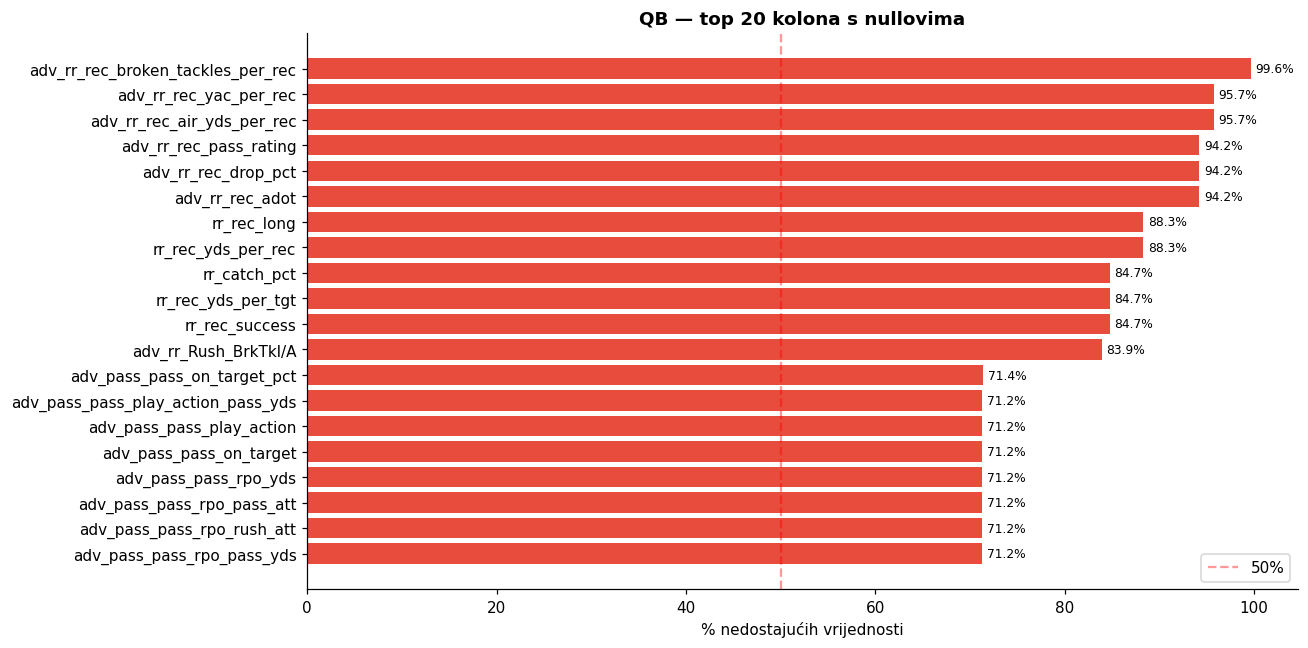

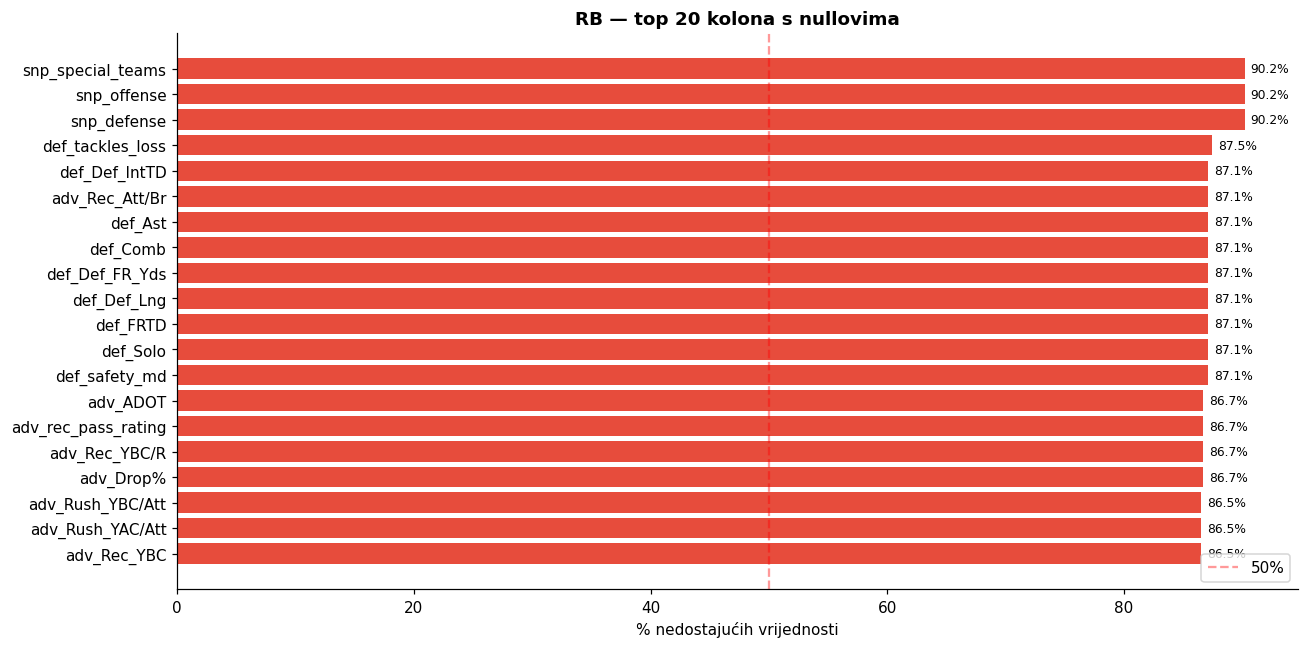

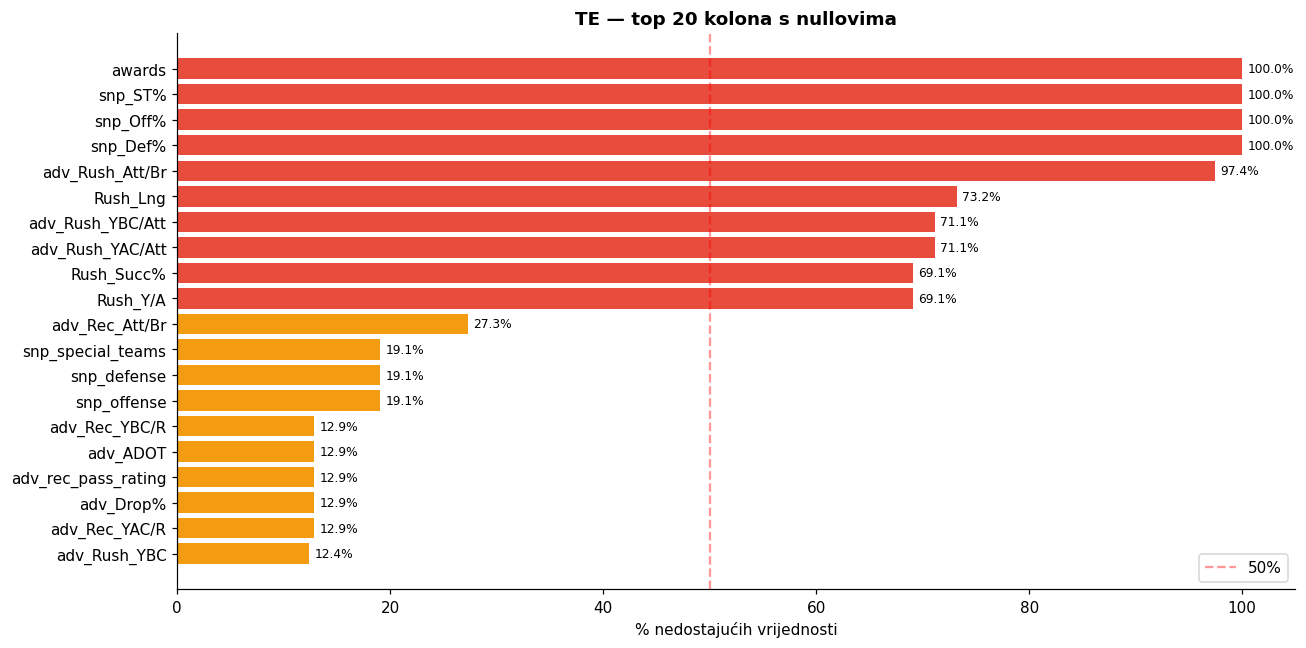

WR: nema nedostajućih vrijednosti.


In [132]:
# Vizualizacija top 20 kolona s najviše nullova po skupu
def plot_missing(df, name, top_n=20):
    null_pct = df.isnull().mean() * 100
    null_pct = null_pct[null_pct > 0].sort_values(ascending=False).head(top_n)
    if null_pct.empty:
        print(f"{name}: nema nedostajućih vrijednosti.")
        return
    fig, ax = plt.subplots(figsize=(12, max(3, len(null_pct) * 0.3)))
    colors = ["#e74c3c" if v >= 50 else "#f39c12" if v >= 10 else "#2ecc71" for v in null_pct.values]
    ax.barh(null_pct.index[::-1], null_pct.values[::-1], color=colors[::-1])
    ax.axvline(50, color="red", linestyle="--", alpha=0.4, label="50%")
    ax.set_xlabel("% nedostajućih vrijednosti")
    ax.set_title(f"{name} — top {len(null_pct)} kolona s nullovima", fontweight="bold")
    ax.legend()
    for i, v in enumerate(null_pct.values[::-1]):
        ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

for name, df in datasets.items():
    plot_missing(df, name.split("(")[0].strip())

Visok procenat null vrednosti u ovim kolonama nije greška u podacima - to je posledica prirode same pozicije. Statistike koje za neku poziciju gotovo i ne postoje jednostavno neće biti popunjene.


 Na primer, QB skupu kolone poput `adv_rr_rec_drop_pct` ili `adv_rr_rec_yac_per_rec` odnose se na receiving metrike — QB praktično nikad nije targetiran kao receiver, pa su te vrijednosti null.


Ove kolone su u skupu podataka prisutne jer se koristi isti šablon kolekcije podataka za sve igrače, ali pri modeliranju će biti isključene ili ignorisane kao nebitne za predviđanje performansi te pozicije.

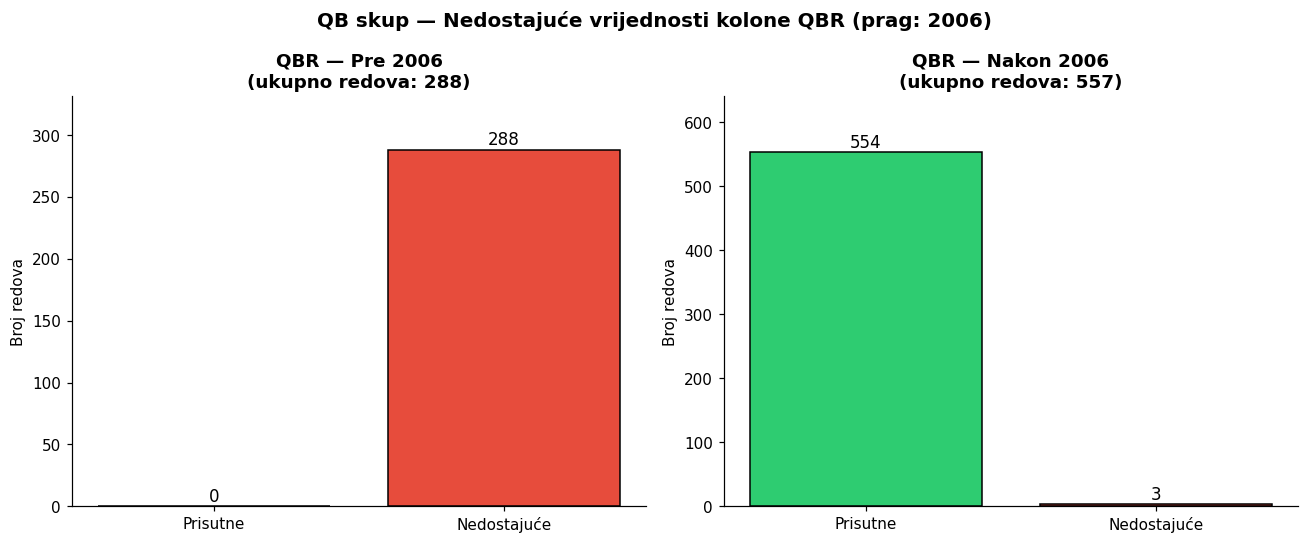

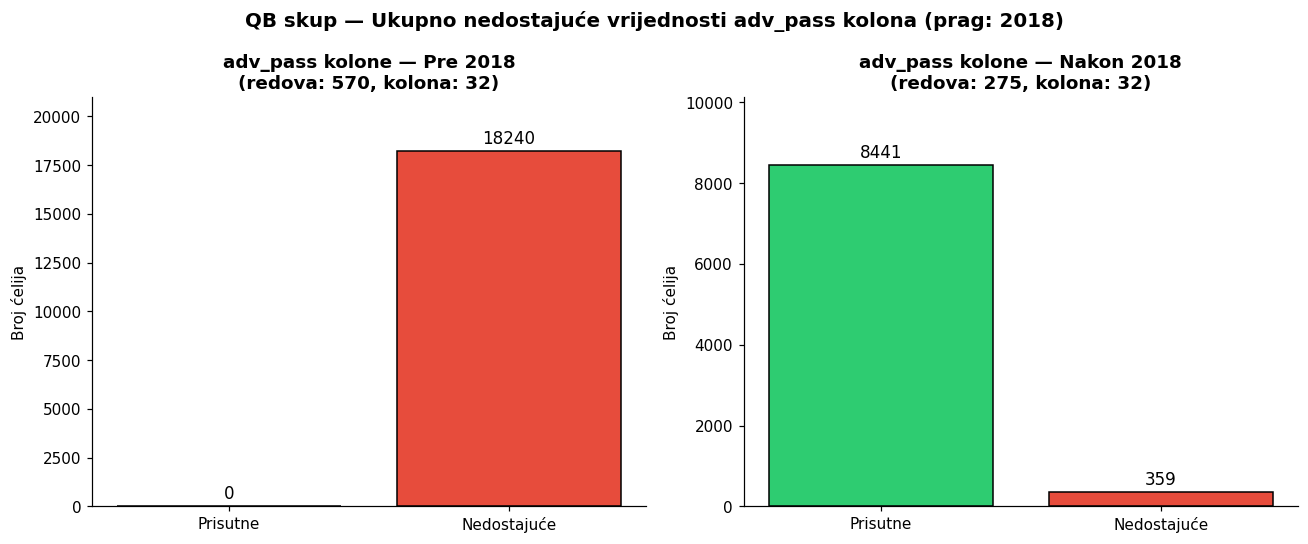

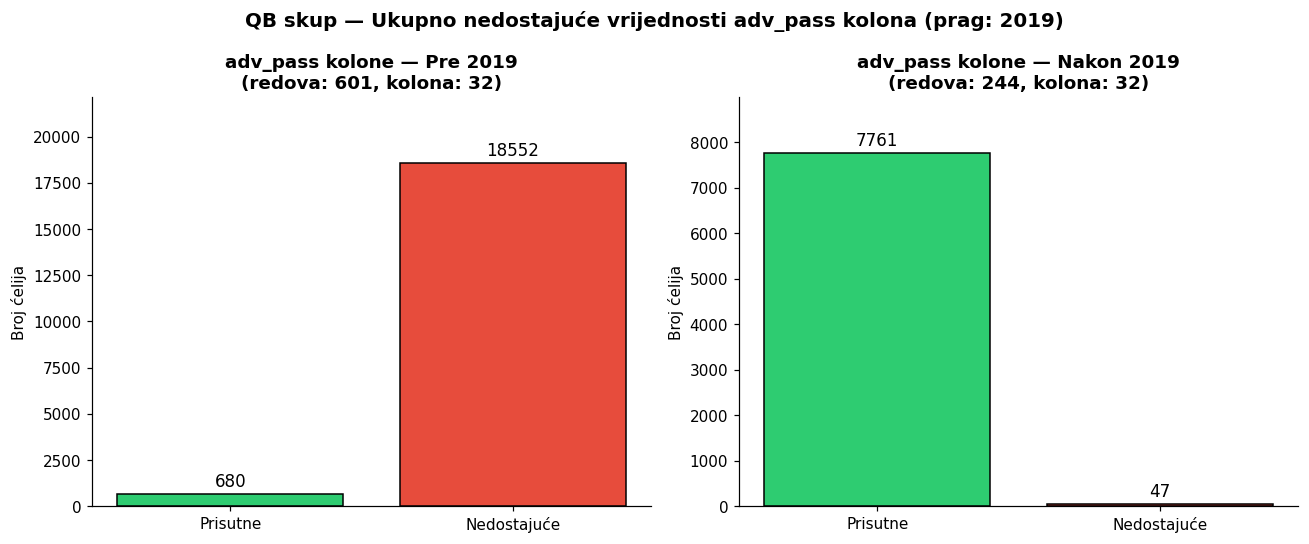

In [133]:

adv_pass_cols = [c for c in qb.columns if c.startswith("adv_pass")]

# --- QBR: broj nedostajućih vrijednosti prije i nakon 2006 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, mask) in zip(axes, [("Pre 2006", qb["Season"] < 2006), ("Nakon 2006", qb["Season"] >= 2006)]):
    subset = qb[mask]
    missing = subset["QBR"].isnull().sum()
    present = subset["QBR"].notnull().sum()
    ax.bar(["Prisutne", "Nedostajuće"], [present, missing], color=["#2ecc71", "#e74c3c"], edgecolor="black")
    ax.set_title(f"QBR — {label}\n(ukupno redova: {len(subset)})", fontweight="bold")
    ax.set_ylabel("Broj redova")
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=11)
    ax.set_ylim(0, len(subset) * 1.15)

fig.suptitle("QB skup — Nedostajuće vrijednosti kolone QBR (prag: 2006)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# --- adv_pass kolone: ukupan broj nedostajućih vrijednosti za različite pragove ---
def plot_adv_pass_missing(year):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (label, mask) in zip(axes, [(f"Pre {year}", qb["Season"] < year), (f"Nakon {year}", qb["Season"] >= year)]):
        subset = qb[mask]
        total_cells = len(subset) * len(adv_pass_cols)
        total_missing = subset[adv_pass_cols].isnull().sum().sum()
        total_present = total_cells - total_missing
        ax.bar(["Prisutne", "Nedostajuće"], [total_present, total_missing], color=["#2ecc71", "#e74c3c"], edgecolor="black")
        ax.set_title(f"adv_pass kolone — {label}\n(redova: {len(subset)}, kolona: {len(adv_pass_cols)})", fontweight="bold")
        ax.set_ylabel("Broj ćelija")
        for bar in ax.patches:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total_cells * 0.01,
                    str(int(bar.get_height())), ha="center", va="bottom", fontsize=11)
        ax.set_ylim(0, total_cells * 1.15)
    fig.suptitle(f"QB skup — Ukupno nedostajuće vrijednosti adv_pass kolona (prag: {year})", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

for year in [2018, 2019]:
    plot_adv_pass_missing(year)



### Interpretacija grafika nedostajućih vrednosti

QBR (prag: 2006)

ESPN Total QBR metrika uvedena je 2006. godine, što objašnjava zašto svih 288 QB sezona pre 2006. nema QBR vrednost (100% null). Nakon 2006. samo 3 od 557 redova nemaju QBR. Ovo je strukturalni nedostatak podataka uslovljen datumom uvođenja metrike, a ne greškom u prikupljanju.

---
adv_pass kolone (prag: 2018)

Pro Football Reference je 2018. godine uveo prvi set naprednih passing statistika (`adv_pass` kolone). Prije te godine nijedna od ovih kolona nije postojala, pa je prisutnost podataka za sezone prije 2018. ravna **0%** — svi redovi su null. Nakon 2018. većina `adv_pass` kolona je popunjena, što potvrđuje da se radi o strukturalnom nedostatku vezanom za datum uvođenja metrika, a ne o greškama u prikupljanju.

---
adv_pass kolone (prag: 2019)

Iako su napredne passing statistike uvedene 2018., skup kolona je **proširen 2019. godine** dodatnim metrikama. Kolone poput **play action yards**, **play action attempts**, **run-pass option (RPO) attempts i yards**, **on-target throws**, **on-target throw %** i druge nisu postojale u sezoni 2018. i počele su se bilježiti tek od 2019. To objašnjava zašto grafik s pragom 2019. pokazuje još manji broj nedostajućih vrijednosti nakon praga — jer su sve `adv_pass` kolone (uključujući i one dodane 2019.) tada potpuno dostupne, dok u sezoni 2018. te novije kolone još uvijek imaju null vrijednosti.
